# Obligatorio - Inteligencia Artificial Generativa  
# WGAN-GP: Una versión mejorada da las GAN "Vanilla"
---

- Diciembre 2025  
- Enrique Oliva - 214205

## Introducción
---

La presente notebook constituye una demostración empírica de las mejoras que introduce WGAN-GP a sus versiones predecesoras, particularmente mediante la comparación de tres arquitecturas de GANs: Vanilla GAN, WGAN y WGAN-GP.

Al comienzo se demuestra el problema de saturación del discriminador que causa gradientes que desaparecen: D(real)→1, D(fake)→0, resultando en un colapso de modo o mode collapse.

WGAN (Arjovsky et al., 2017) soluciona esto reemplazando BCE loss por distancia Wasserstein con un crítico sin sigmoid, pero introduce clipping de los pesos (o weight clipping) que fuerza los pesos a ±0.01 causando distribución bimodal y gradientes explosivos.

WGAN-GP (Gulrajani et al., 2017) reemplaza el clipping por un gradient penalty (λ=10) que fuerza la restricción de Lipschitz (concepto a explicar más abajo) de forma suave, permitiendo distribución natural de pesos y gradientes estables (varianza 691× mejor que WGAN).

Los tres modelos se entrenan sobre CIFAR-10 con arquitecturas DCGAN compartidas. La sección de evaluación demuestra progresivamente cada problema y su solución mediante visualizaciones de: saturación D(real)/D(fake), distancia Wasserstein, distribución de pesos (bimodal vs Gaussiana), normas de gradientes, evolución del GP, y calidad de muestras generadas.

Nota sobre "Vanilla GAN": El paper original de Goodfellow et al. (2014) usó MLPs con activaciones Maxout y Dropout. Siguiendo la práctica estándar moderna, se implementó la Vanilla GAN como GAN con BCE loss usando arquitectura DCGAN (CNNs con BatchNorm), ya que el término se refiere conceptualmente a la función objetivo original, no a la arquitectura específica de 2014. Esto permite una comparación justa de las funciones de pérdida manteniendo la arquitectura constante.

Referencias:
- [Generative Adversarial Nets (Goodfellow et al., 2014)](https://arxiv.org/abs/1406.2661)
- [Wasserstein GAN (Arjovsky et al., 2017)](https://arxiv.org/abs/1701.07875)
- [Improved Training of Wasserstein GANs (Gulrajani et al., 2017)](https://arxiv.org/abs/1704.00028)

## Configuración general
---

### Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
import wandb

### Semilla para reproducibilidad

In [2]:
torch.manual_seed(42)
np.random.seed(42)

### Configuración de dispositivo

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070


### Configuración de salidas y logging

In [4]:
os.environ["WANDB_SILENT"] = "true"

BASE_OUTPUT_DIR = "./outputs"
EXPERIMENT_NAME = "wgan_comparison"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = f"{BASE_OUTPUT_DIR}/{EXPERIMENT_NAME}_{TIMESTAMP}"
MODELS_DIR = f"{RESULTS_DIR}/models"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
DATA_DIR = "./data"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

USE_WANDB = True
WANDB_PROJECT = "Obligatorio de IA Generativa 2025"
WANDB_ENTITY = "eo214205-ort"
WANDB_GROUP = datetime.now().strftime("%d/%m/%y - %H:%M")

## Hiperparámetros
---

### Hiperparámetros comunes a los 3 modelos

In [5]:
BATCH_SIZE = 64
IMAGE_SIZE = 32
NUM_CHANNELS = 3
LATENT_DIM = 128
GENERATOR_FEATURES = 128
NUM_EPOCHS = 150

### Vanilla GAN

In [6]:
VANILLA_LR = 0.01
VANILLA_MOMENTUM = 0.9
VANILLA_DISCRIMINATOR_FEATURES = 128

### WGAN

In [7]:
WGAN_LR = 5e-5
WGAN_CLIP = 0.01
WGAN_CRITIC_FEATURES = 128
WGAN_CRITIC_ITERATIONS = 5

### WGAN-GP

In [8]:
WGANGP_LR = 1e-4
WGANGP_LAMBDA = 10
WGANGP_BETAS = (0.0, 0.9)
WGANGP_CRITIC_FEATURES = 128
WGANGP_CRITIC_ITERATIONS = 5

## Carga y análisis del dataset
---

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=transform
)

dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
)

print(f"Dataset: CIFAR-10")
print(f"Imágenes: {len(train_dataset)}")
print(f"Batches/época: {len(dataloader)}")

Files already downloaded and verified
Dataset: CIFAR-10
Imágenes: 50000
Batches/época: 781


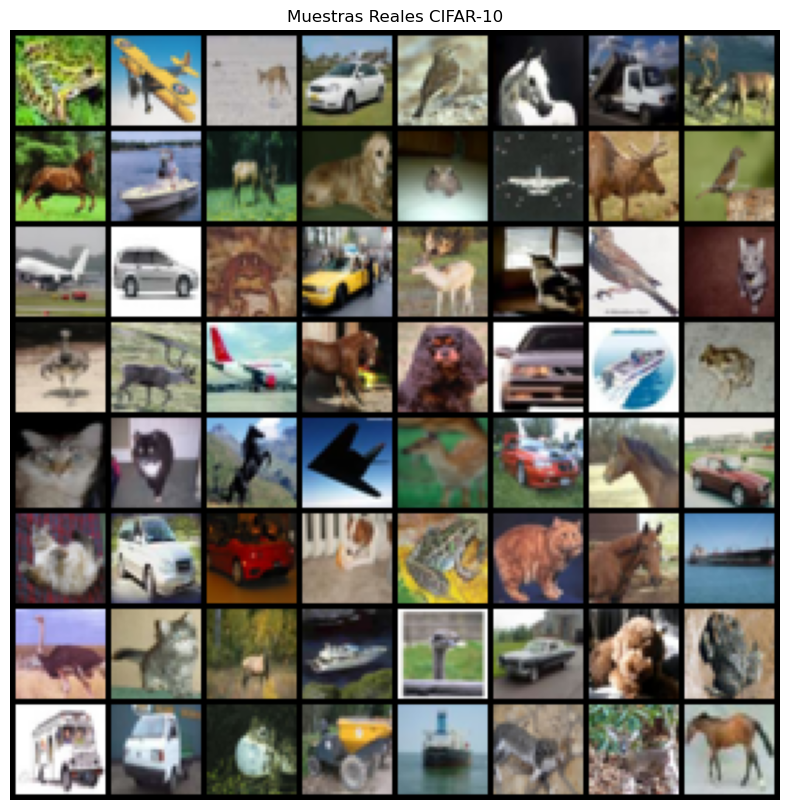

In [10]:
real_batch = next(iter(dataloader))[0]
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Muestras Reales CIFAR-10")
plt.imshow(np.transpose(
    vutils.make_grid(real_batch[:64], padding=2, normalize=True, nrow=8).cpu(),
    (1, 2, 0)
))
plt.show()

## Implementación de los modelos
---



### Generador (compartido por las 3 variantes)

In [11]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_features, num_channels):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, num_features * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(num_features * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 4, num_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 2, num_features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features, num_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.BatchNorm2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, z):
        return self.main(z)

test_gen = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
test_z = torch.randn(1, LATENT_DIM, 1, 1, device=device)
test_out = test_gen(test_z)
del test_gen, test_z, test_out

### Discriminador Vanilla GAN

In [12]:
class VanillaDiscriminator(nn.Module):
    def __init__(self, num_channels, num_features):
        super(VanillaDiscriminator, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(num_channels, num_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features, num_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 2, num_features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
        
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.BatchNorm2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, x):
        return self.main(x).view(-1)

test_disc = VanillaDiscriminator(NUM_CHANNELS, VANILLA_DISCRIMINATOR_FEATURES).to(device)
test_img = torch.randn(1, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_out = test_disc(test_img)
del test_disc, test_img, test_out

### Discriminador (ahora Critic) WGAN/WGAN-GP

In [13]:
class Critic(nn.Module):
    def __init__(self, num_channels, num_features):
        super(Critic, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(num_channels, num_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features, num_features * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 2, num_features * 4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 4, 1, 4, 1, 0, bias=False)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, x):
        return self.main(x).view(-1)

test_critic = Critic(NUM_CHANNELS, WGAN_CRITIC_FEATURES).to(device)
test_img = torch.randn(1, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_out = test_critic(test_img)
del test_critic, test_img, test_out

### Optimizador Vanilla GAN

In [14]:
def get_vanilla_optimizers(generator, discriminator):
    optimizer_G = optim.SGD(generator.parameters(), lr=VANILLA_LR, momentum=VANILLA_MOMENTUM)
    optimizer_D = optim.SGD(discriminator.parameters(), lr=VANILLA_LR, momentum=VANILLA_MOMENTUM)
    return optimizer_G, optimizer_D

### Optimizador WGAN

In [15]:
def get_wgan_optimizers(generator, critic):
    optimizer_G = optim.RMSprop(generator.parameters(), lr=WGAN_LR)
    optimizer_C = optim.RMSprop(critic.parameters(), lr=WGAN_LR)
    return optimizer_G, optimizer_C

### Optimizador WGAN-GP

In [16]:
def get_wgangp_optimizers(generator, critic):
    optimizer_G = optim.Adam(generator.parameters(), lr=WGANGP_LR, betas=WGANGP_BETAS)
    optimizer_C = optim.Adam(critic.parameters(), lr=WGANGP_LR, betas=WGANGP_BETAS)
    return optimizer_G, optimizer_C

### Loss Vanilla GAN

In [17]:
criterion_bce = nn.BCELoss()

### Loss WGAN

In [18]:
def wgan_critic_loss(critic_real, critic_fake):
    return -(critic_real - critic_fake)

def wgan_generator_loss(critic_fake):
    return -critic_fake

### Loss WGAN-GP

In [19]:
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_samples)
    
    interpolated = alpha * real_samples + (1 - alpha) * fake_samples
    interpolated.requires_grad_(True)
    
    critic_interpolated = critic(interpolated)
    
    gradients = autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()
    
    return gradient_penalty

def wgangp_critic_loss(critic_real, critic_fake, gp):
    return -(critic_real - critic_fake) + WGANGP_LAMBDA * gp

def wgangp_generator_loss(critic_fake):
    return -critic_fake

### Utilidades compartidas

In [20]:
class TrainingMetrics:
    def __init__(self):
        self.critic_losses = []
        self.generator_losses = []
        self.d_real_outputs = []
        self.d_fake_outputs = []
        self.gradient_norms = []
        self.gradient_penalties = []
        self.training_time = 0
        self.generated_samples = []
        self.iterations = []
    
    def log(self, iteration, c_loss, g_loss, d_real, d_fake):
        self.iterations.append(iteration)
        self.critic_losses.append(c_loss)
        self.generator_losses.append(g_loss)
        self.d_real_outputs.append(d_real)
        self.d_fake_outputs.append(d_fake)
    
    def log_gp(self, gp):
        self.gradient_penalties.append(gp)
    
    def log_gradients(self, critic_grads):
        total = sum(critic_grads.values())
        self.gradient_norms.append(total)
    
    def save_samples(self, samples):
        self.generated_samples.append(samples.detach().cpu())

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.data.norm(2).item()
    return norms

def get_all_weights(model):
    weights = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            weights.extend(param.data.cpu().numpy().flatten())
    return np.array(weights)

## Entrenamiento de los modelos
---

### Entrenamiento Vanilla GAN

In [21]:
def train_vanilla_gan(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name="Vanilla GAN", config={"modelo": "Vanilla GAN", "lr": VANILLA_LR, "momentum": VANILLA_MOMENTUM, "epocas": num_epochs})
    
    print(f"Entrenando Vanilla GAN: lr={VANILLA_LR}, momentum={VANILLA_MOMENTUM}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    discriminator = VanillaDiscriminator(NUM_CHANNELS, VANILLA_DISCRIMINATOR_FEATURES).to(device)
    optimizer_G, optimizer_D = get_vanilla_optimizers(generator, discriminator)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            optimizer_D.zero_grad()
            labels_real = torch.ones(batch_size, device=device)
            labels_fake = torch.zeros(batch_size, device=device)
            
            output_real = discriminator(real_images)
            d_loss_real = criterion_bce(output_real, labels_real)
            d_loss_real.backward()
            
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            output_fake = discriminator(fake_images.detach())
            d_loss_fake = criterion_bce(output_fake, labels_fake)
            d_loss_fake.backward()
            
            d_loss = d_loss_real + d_loss_fake
            optimizer_D.step()
            
            optimizer_G.zero_grad()
            output_fake_g = discriminator(fake_images)
            g_loss = criterion_bce(output_fake_g, labels_real)
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                d_real = output_real.mean().item()
                d_fake = output_fake.mean().item()
                metrics.log(iteration, d_loss.item(), g_loss.item(), d_real, d_fake)
                metrics.log_gradients(get_gradient_norms(discriminator))
                
                if USE_WANDB:
                    wandb.log({"loss_D": d_loss.item(), "loss_G": g_loss.item(), "D_real": d_real, "D_fake": d_fake})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, discriminator, metrics

In [22]:
vanilla_gen, vanilla_disc, vanilla_metrics = train_vanilla_gan(dataloader, NUM_EPOCHS)

Entrenando Vanilla GAN: lr=0.01, momentum=0.9, épocas=150
Época 150/150
Completado: 23.08 min


### Entrenamiento WGAN

In [23]:
def train_wgan(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name=f"WGAN (c={WGAN_CLIP})", config={"modelo": "WGAN", "lr": WGAN_LR, "clip": WGAN_CLIP})
    
    print(f"Entrenando WGAN: lr={WGAN_LR}, c={WGAN_CLIP}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    critic = Critic(NUM_CHANNELS, WGAN_CRITIC_FEATURES).to(device)
    optimizer_G, optimizer_C = get_wgan_optimizers(generator, critic)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            for _ in range(WGAN_CRITIC_ITERATIONS):
                optimizer_C.zero_grad()
                
                z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
                fake_images = generator(z).detach()
                
                critic_real = critic(real_images).mean()
                critic_fake = critic(fake_images).mean()
                
                c_loss = wgan_critic_loss(critic_real, critic_fake)
                c_loss.backward()
                optimizer_C.step()
                
                for p in critic.parameters():
                    p.data.clamp_(-WGAN_CLIP, WGAN_CLIP)
            
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            g_loss = wgan_generator_loss(critic(fake_images).mean())
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                c_real = critic_real.item()
                c_fake = critic_fake.item()
                metrics.log(iteration, c_loss.item(), g_loss.item(), c_real, c_fake)
                metrics.log_gradients(get_gradient_norms(critic))
                
                if USE_WANDB:
                    wandb.log({"loss_C": c_loss.item(), "loss_G": g_loss.item(), "C_real": c_real, "C_fake": c_fake})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, critic, metrics

In [24]:
wgan_gen, wgan_critic, wgan_metrics = train_wgan(dataloader, NUM_EPOCHS)

Entrenando WGAN: lr=5e-05, c=0.01, épocas=150
Época 150/150
Completado: 65.78 min


### Entrenamiento WGAN-GP

In [25]:
def train_wgangp(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name=f"WGAN-GP (λ={WGANGP_LAMBDA})", config={"modelo": "WGAN-GP", "lr": WGANGP_LR, "lambda": WGANGP_LAMBDA})
    
    print(f"Entrenando WGAN-GP: lr={WGANGP_LR}, λ={WGANGP_LAMBDA}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    critic = Critic(NUM_CHANNELS, WGANGP_CRITIC_FEATURES).to(device)
    optimizer_G, optimizer_C = get_wgangp_optimizers(generator, critic)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            for _ in range(WGANGP_CRITIC_ITERATIONS):
                optimizer_C.zero_grad()
                
                z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
                fake_images = generator(z)
                
                critic_real = critic(real_images).mean()
                critic_fake = critic(fake_images).mean()
                gp = compute_gradient_penalty(critic, real_images, fake_images, device)
                
                c_loss = wgangp_critic_loss(critic_real, critic_fake, gp)
                c_loss.backward()
                optimizer_C.step()
            
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            g_loss = wgangp_generator_loss(critic(fake_images).mean())
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                c_real = critic_real.item()
                c_fake = critic_fake.item()
                metrics.log(iteration, c_loss.item(), g_loss.item(), c_real, c_fake)
                metrics.log_gp(gp.item())
                metrics.log_gradients(get_gradient_norms(critic))
                
                if USE_WANDB:
                    wandb.log({"loss_C": c_loss.item(), "loss_G": g_loss.item(), "C_real": c_real, "C_fake": c_fake, "GP": gp.item()})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, critic, metrics

In [26]:
wgangp_gen, wgangp_critic, wgangp_metrics = train_wgangp(dataloader, NUM_EPOCHS)

Entrenando WGAN-GP: lr=0.0001, λ=10, épocas=150
Época 150/150
Completado: 124.40 min


## Evaluación de los modelos
---

### Figura 1 - Vanilla GAN: Saturación del Discriminador

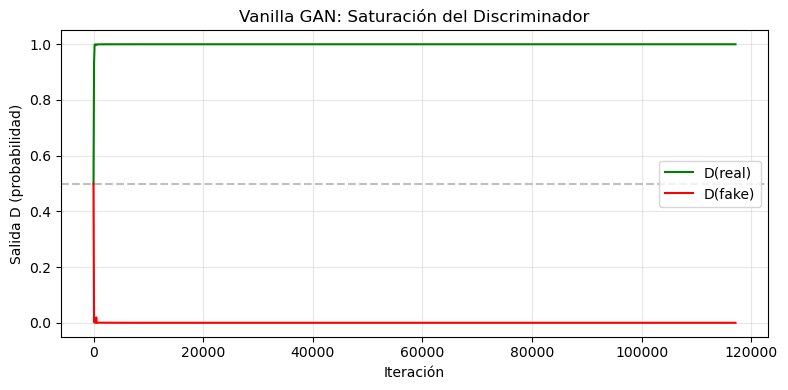

D(real) → 1.000, D(fake) → 0.000


In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(vanilla_metrics.iterations, vanilla_metrics.d_real_outputs, label='D(real)', color='green', linewidth=1.5)
ax.plot(vanilla_metrics.iterations, vanilla_metrics.d_fake_outputs, label='D(fake)', color='red', linewidth=1.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Iteración')
ax.set_ylabel('Salida D (probabilidad)')
ax.set_title('Vanilla GAN: Saturación del Discriminador')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/1_vanilla_saturation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"D(real) → {vanilla_metrics.d_real_outputs[-1]:.3f}, D(fake) → {vanilla_metrics.d_fake_outputs[-1]:.3f}")

### Figura 2 - WGAN: Distancia Wasserstein

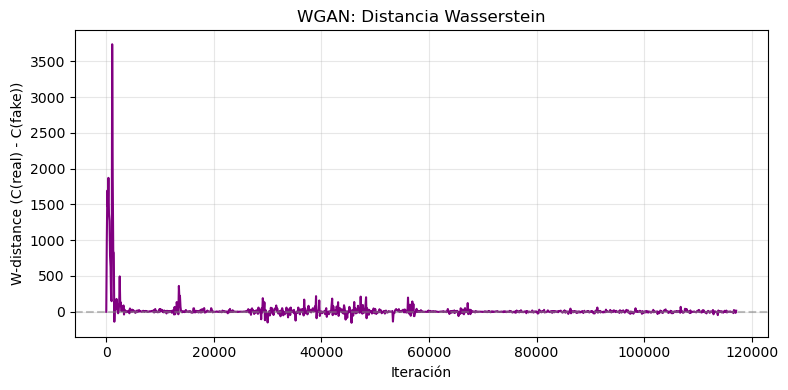

W-distance final: 15.6595


In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

w_distance = [r - f for r, f in zip(wgan_metrics.d_real_outputs, wgan_metrics.d_fake_outputs)]
ax.plot(wgan_metrics.iterations, w_distance, color='purple', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Iteración')
ax.set_ylabel('W-distance (C(real) - C(fake))')
ax.set_title('WGAN: Distancia Wasserstein')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/2_wgan_wdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"W-distance final: {w_distance[-1]:.4f}")

### Figura 3 - Comparación de los pesos entre Vanilla GAN y WGAN

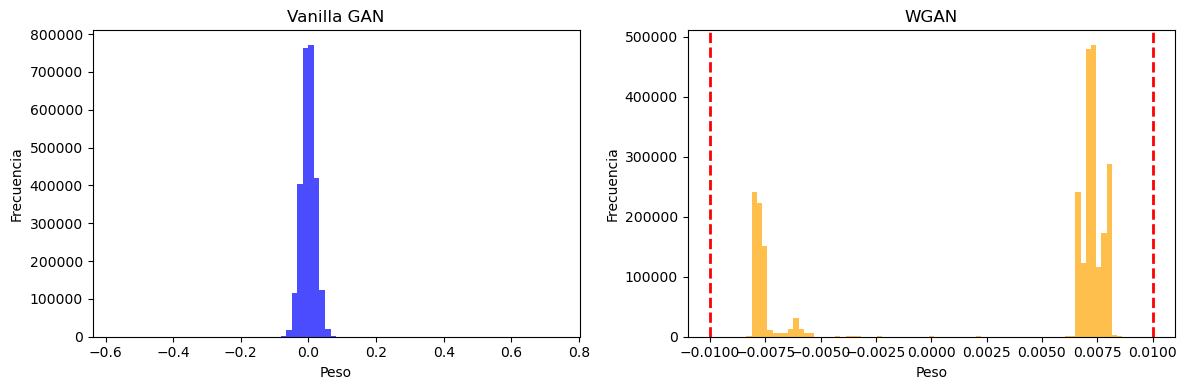

Vanilla: rango [-0.573, 0.736]
WGAN: rango [-0.010, 0.009]


In [29]:
vanilla_weights = get_all_weights(vanilla_disc)
wgan_weights = get_all_weights(wgan_critic)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vanilla_weights, bins=80, color='blue', alpha=0.7)
axes[0].set_xlabel('Peso')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Vanilla GAN')

axes[1].hist(wgan_weights, bins=80, color='orange', alpha=0.7)
axes[1].axvline(x=-WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Peso')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('WGAN')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/3_weight_clipping.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Vanilla: rango [{vanilla_weights.min():.3f}, {vanilla_weights.max():.3f}]")
print(f"WGAN: rango [{wgan_weights.min():.3f}, {wgan_weights.max():.3f}]")

### Figura 4 - Comparación de gradientes

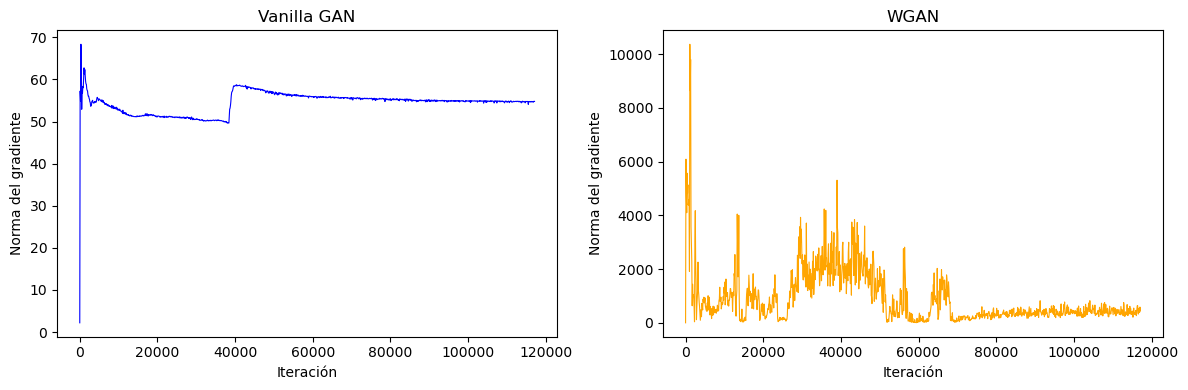

Varianza Vanilla: 8
Varianza WGAN: 9.84e+05


In [30]:
ig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(vanilla_metrics.iterations, vanilla_metrics.gradient_norms, color='blue', linewidth=0.8)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Norma del gradiente')
axes[0].set_title('Vanilla GAN')

axes[1].plot(wgan_metrics.iterations, wgan_metrics.gradient_norms, color='orange', linewidth=0.8)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Norma del gradiente')
axes[1].set_title('WGAN')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/4_gradient_instability.png', dpi=150, bbox_inches='tight')
plt.show()

vanilla_var = np.var(vanilla_metrics.gradient_norms)
wgan_var = np.var(wgan_metrics.gradient_norms)
print(f"Varianza Vanilla: {vanilla_var:.0f}")
print(f"Varianza WGAN: {wgan_var:.2e}")

### Figura 5 - Comparación de los pesos entre WGAN y WGAN-GP

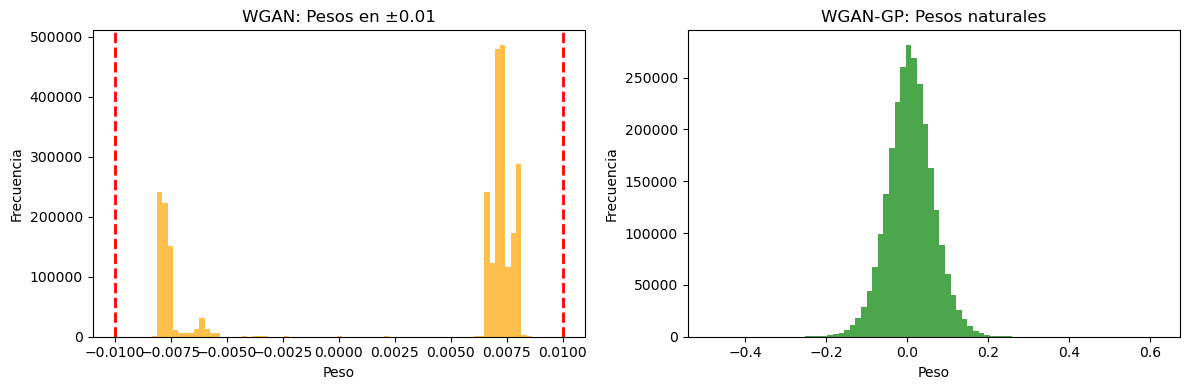

WGAN std: 0.0067
WGAN-GP std: 0.0571


In [31]:
wgangp_weights = get_all_weights(wgangp_critic)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(wgan_weights, bins=80, color='orange', alpha=0.7)
axes[0].axvline(x=-WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[0].axvline(x=WGAN_CLIP, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Peso')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'WGAN: Pesos en ±{WGAN_CLIP}')

axes[1].hist(wgangp_weights, bins=80, color='green', alpha=0.7)
axes[1].set_xlabel('Peso')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('WGAN-GP: Pesos naturales')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/5_wgangp_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"WGAN std: {wgan_weights.std():.4f}")
print(f"WGAN-GP std: {wgangp_weights.std():.4f}")

### Figura 6 - Comparación de gradientes entre WGAN y WGAN-GP, y visualización del Gradient Penalty del WGAN-GP

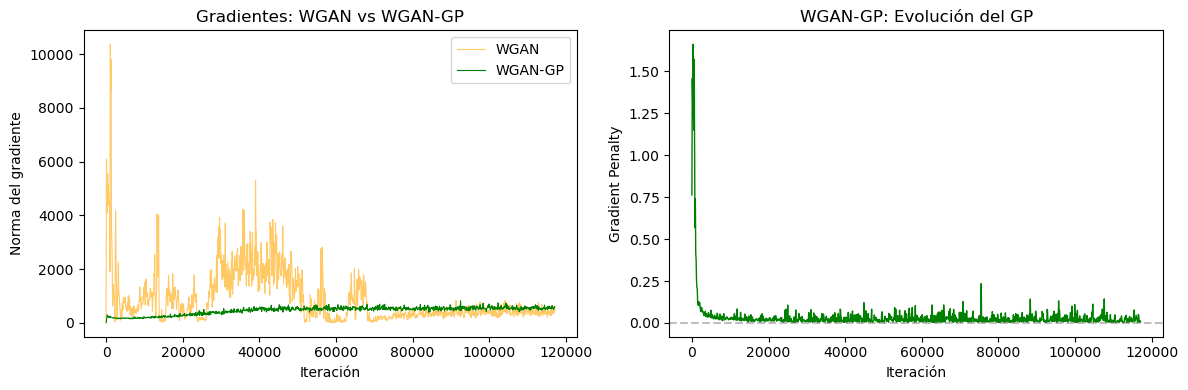

Varianza WGAN: 9.84e+05
Varianza WGAN-GP: 19449
GP final: 0.0046


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(wgan_metrics.iterations, wgan_metrics.gradient_norms, color='orange', alpha=0.6, linewidth=0.8, label='WGAN')
axes[0].plot(wgangp_metrics.iterations, wgangp_metrics.gradient_norms, color='green', linewidth=0.8, label='WGAN-GP')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Norma del gradiente')
axes[0].set_title('Gradientes: WGAN vs WGAN-GP')
axes[0].legend()

gp_iters = wgangp_metrics.iterations[:len(wgangp_metrics.gradient_penalties)]
axes[1].plot(gp_iters, wgangp_metrics.gradient_penalties, color='green', linewidth=1)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Gradient Penalty')
axes[1].set_title('WGAN-GP: Evolución del GP')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/6_wgangp_gradients.png', dpi=150, bbox_inches='tight')
plt.show()

wgan_var = np.var(wgan_metrics.gradient_norms)
wgangp_var = np.var(wgangp_metrics.gradient_norms)
print(f"Varianza WGAN: {wgan_var:.2e}")
print(f"Varianza WGAN-GP: {wgangp_var:.0f}")
print(f"GP final: {wgangp_metrics.gradient_penalties[-1]:.4f}")

### Figura 7 - Muestras generadas

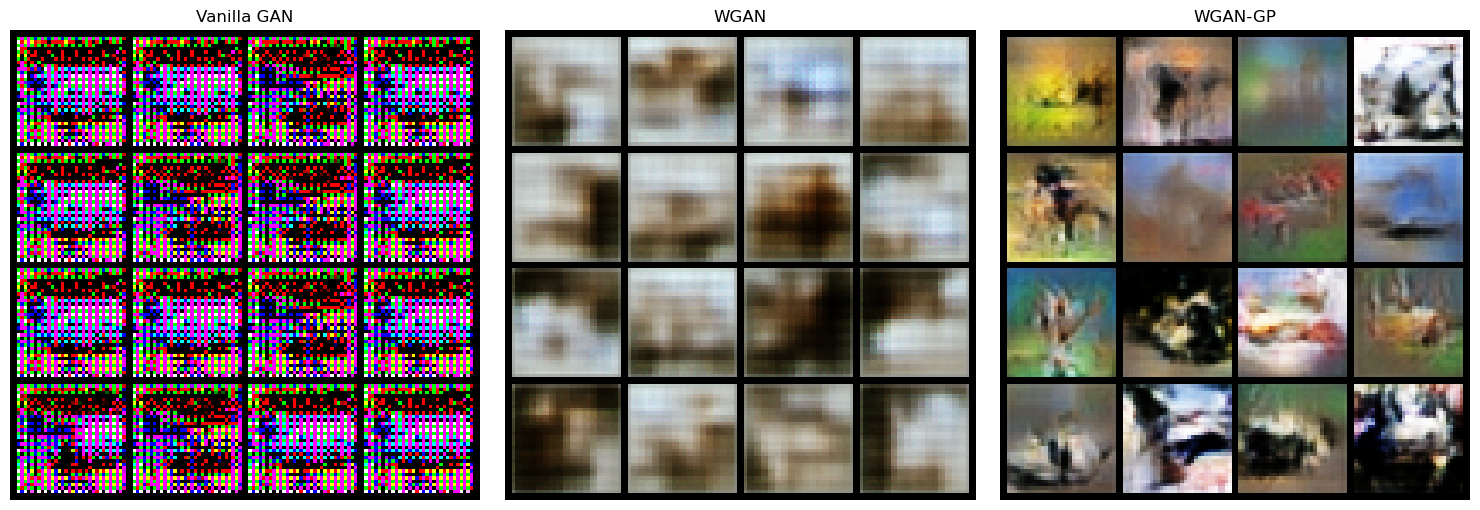

RESUMEN
Modelo       Tiempo     Var. Grad    Peso std  
Vanilla      23.1       8            0.0206    
WGAN         65.8       9.84e+05     0.0067    
WGAN-GP      124.4      19449        0.0571    


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

samples_v = vanilla_metrics.generated_samples[-1][:16]
grid_v = vutils.make_grid(samples_v, nrow=4, normalize=True, padding=2)
axes[0].imshow(np.transpose(grid_v.numpy(), (1, 2, 0)))
axes[0].set_title('Vanilla GAN')
axes[0].axis('off')

samples_w = wgan_metrics.generated_samples[-1][:16]
grid_w = vutils.make_grid(samples_w, nrow=4, normalize=True, padding=2)
axes[1].imshow(np.transpose(grid_w.numpy(), (1, 2, 0)))
axes[1].set_title('WGAN')
axes[1].axis('off')

samples_gp = wgangp_metrics.generated_samples[-1][:16]
grid_gp = vutils.make_grid(samples_gp, nrow=4, normalize=True, padding=2)
axes[2].imshow(np.transpose(grid_gp.numpy(), (1, 2, 0)))
axes[2].set_title('WGAN-GP')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/7_final_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("RESUMEN")

print(f"{'Modelo':<12} {'Tiempo':<10} {'Var. Grad':<12} {'Peso std':<10}")

print(f"{'Vanilla':<12} {vanilla_metrics.training_time/60:<10.1f} {np.var(vanilla_metrics.gradient_norms):<12.0f} {vanilla_weights.std():<10.4f}")
print(f"{'WGAN':<12} {wgan_metrics.training_time/60:<10.1f} {np.var(wgan_metrics.gradient_norms):<12.2e} {wgan_weights.std():<10.4f}")
print(f"{'WGAN-GP':<12} {wgangp_metrics.training_time/60:<10.1f} {np.var(wgangp_metrics.gradient_norms):<12.0f} {wgangp_weights.std():<10.4f}")

In [36]:
print("RESUMEN COMPARATIVO")

print("\nTIEMPOS DE ENTRENAMIENTO:")
print(f"  Vanilla GAN: {vanilla_metrics.training_time/60:.2f} min")
print(f"  WGAN:        {wgan_metrics.training_time/60:.2f} min (5x critic iterations)")
print(f"  WGAN-GP:     {wgangp_metrics.training_time/60:.2f} min (5x critic iterations + GP)")

print("\nWASSERSTEIN DISTANCE FINAL (solo WGAN/WGAN-GP):")
wgan_final_w = wgan_metrics.d_real_outputs[-1] - wgan_metrics.d_fake_outputs[-1]
wgangp_final_w = wgangp_metrics.d_real_outputs[-1] - wgangp_metrics.d_fake_outputs[-1]
print(f"  WGAN:    {wgan_final_w:.4f}")
print(f"  WGAN-GP: {wgangp_final_w:.4f}")

print("\nDISTRIBUCIÓN DE PESOS:")
print(f"  Vanilla GAN: rango=[{vanilla_weights.min():.4f}, {vanilla_weights.max():.4f}], std={vanilla_weights.std():.4f}")
print(f"  WGAN:        rango=[{wgan_weights.min():.4f}, {wgan_weights.max():.4f}], std={wgan_weights.std():.4f}")
print(f"  WGAN-GP:     rango=[{wgangp_weights.min():.4f}, {wgangp_weights.max():.4f}], std={wgangp_weights.std():.4f}")

print("\nESTABILIDAD DE GRADIENTES (varianza):")
print(f"  Vanilla GAN: {np.var(vanilla_metrics.gradient_norms):.4f}")
print(f"  WGAN:        {np.var(wgan_metrics.gradient_norms):.4f}")
print(f"  WGAN-GP:     {np.var(wgangp_metrics.gradient_norms):.4f}")

print("\n" + "="*70)

RESUMEN COMPARATIVO

TIEMPOS DE ENTRENAMIENTO:
  Vanilla GAN: 23.08 min
  WGAN:        65.78 min (5x critic iterations)
  WGAN-GP:     124.40 min (5x critic iterations + GP)

WASSERSTEIN DISTANCE FINAL (solo WGAN/WGAN-GP):
  WGAN:    15.6595
  WGAN-GP: 1.2201

DISTRIBUCIÓN DE PESOS:
  Vanilla GAN: rango=[-0.5731, 0.7362], std=0.0206
  WGAN:        rango=[-0.0100, 0.0089], std=0.0067
  WGAN-GP:     rango=[-0.4868, 0.6185], std=0.0571

ESTABILIDAD DE GRADIENTES (varianza):
  Vanilla GAN: 7.6776
  WGAN:        983839.6050
  WGAN-GP:     19449.1499



In [37]:
torch.save(vanilla_gen.state_dict(), f'{MODELS_DIR}/vanilla_gen.pth')
torch.save(vanilla_disc.state_dict(), f'{MODELS_DIR}/vanilla_disc.pth')
torch.save(wgan_gen.state_dict(), f'{MODELS_DIR}/wgan_gen.pth')
torch.save(wgan_critic.state_dict(), f'{MODELS_DIR}/wgan_critic.pth')
torch.save(wgangp_gen.state_dict(), f'{MODELS_DIR}/wgangp_gen.pth')
torch.save(wgangp_critic.state_dict(), f'{MODELS_DIR}/wgangp_critic.pth')

print(f"Modelos guardados en: {MODELS_DIR}")

Modelos guardados en: ./outputs/wgan_comparison_20251208_162624/models


## Explicación / Justificación de la notebook

### Objetivo

Demostrar empíricamente los problemas de Vanilla GAN y WGAN, y cómo WGAN-GP los resuelve. Para esto se entrenaron los tres modelos bajo las mismas condiciones y se compararon métricas específicas.

### Dataset

Se eligió CIFAR-10 (imágenes a color 32×32) en lugar de MNIST porque su mayor complejidad hace más evidentes las diferencias entre modelos. Las imágenes se normalizaron a [-1, 1] para coincidir con la salida Tanh del generador.

### Arquitectura

Se usó la misma arquitectura de generador para los tres modelos. Esto permite atribuir las diferencias en resultados exclusivamente a la función de pérdida, no a la arquitectura.

#### Generador (compartido)

Basado en la arquitectura DCGAN (Radford et al., 2015): convoluciones transpuestas que expanden el vector latente Z (128 dimensiones) hasta una imagen de 32×32×3. Cada capa usa BatchNorm y ReLU, excepto la última que usa Tanh para producir valores en [-1, 1].

#### Discriminador Vanilla GAN

Arquitectura espejo del generador: convoluciones que reducen la imagen hasta un escalar. Usa LeakyReLU (pendiente 0.2) y BatchNorm en capas internas. Termina en Sigmoid para producir probabilidades en [0, 1], como especifica el paper original de Goodfellow et al. (2014).

#### Crítico WGAN / WGAN-GP

Similar al discriminador pero sin Sigmoid al final, produciendo puntajes sin límites. Esto es requisito matemático de la distancia Wasserstein según Arjovsky et al. (2017). Además, siguiendo la recomendación del paper de WGAN-GP (Gulrajani et al., 2017), no se usa BatchNorm en el crítico cuando se aplica gradient penalty.


### Restricción de Lipschitz

Una función es 1-Lipschitz si no puede cambiar su salida más rápido que su entrada. Formalmente: |f(x₁) - f(x₂)| ≤ |x₁ - x₂| para todo par de puntos.

¿Por qué importa? La distancia Wasserstein solo tiene sentido matemático si el crítico es 1-Lipschitz. Sin esta restricción, el crítico podría dar valores arbitrariamente grandes, haciendo la métrica inútil.

¿Cómo se ejerce?
- WGAN: Recorta los pesos a [-0.01, 0.01] después de cada paso (weight clipping). Funciona pero es una solución burda que limita la capacidad del crítico.
- WGAN-GP: Añade un término de penalización que castiga cuando ||∇C|| ≠ 1. Es una solución más elegante que permite pesos naturales.

### Hiperparámetros

Todos los valores fueron tomados de los papers originales:

- Vanilla GAN: SGD con momentum (el paper no especifica valores exactos)
- WGAN: RMSprop, lr=5e-5, clip=0.01, n_critic=5
- WGAN-GP: Adam (β₁=0, β₂=0.9), lr=1e-4, λ=10, n_critic=5

### Métricas

- D(real), D(fake): Saturación del discriminador
- Distribución de pesos: Efecto del weight clipping
- Norma de gradientes: Estabilidad del entrenamiento
- Gradient penalty: Convergencia de la restricción Lipschitz
- Muestras generadas: Calidad visual final

### Duración del Entrenamiento

Se entrenaron 150 épocas por modelo, suficientes para observar convergencia o colapso. El tiempo total fue ~3.5 horas (Vanilla: ~23 min, WGAN: ~66 min, WGAN-GP: ~124 min).

## Conclusiones
---

### El Problema Original: Vanilla GAN

En la figura 1, apenas empieza el entrenamiento, el discriminador ya sabe perfectamente distinguir lo real de lo falso:

- D(real) → 1.000 (el discriminador está 100% seguro de que las reales son reales)
- D(fake) → 0.000 (el discriminador está 100% seguro de que las falsas son falsas)

Esto pasa en las primeras iteraciones y nunca cambia. El discriminador "ganó" el juego demasiado rápido.

La pérdida de Vanilla GAN usa BCE (Binary Cross-Entropy). Cuando D(fake) → 0, el gradiente desaparece. El generador recibe una señal que dice "es malo" pero no indica cuánto de malo ni cómo mejorar.

### Solución de WGAN

Arjovsky et al. (2017) propusieron reemplazar BCE por la distancia Wasserstein.

1. El discriminador ahora se llama "crítico" y no tiene sigmoid al final
2. En lugar de dar probabilidades (0 a 1), da puntajes sin límites
3. La pérdida es simplemente C(real) - C(fake)

La figura 2 muestra que la W-distance no colapsa a cero. Fluctúa durante todo el entrenamiento, indicando que el crítico siempre está dando información útil al generador.


### Nuevo Problema: Weight Clipping

WGAN introdujo un problema nuevo. Para que la matemática de Wasserstein funcione, el crítico tiene que ser 1-Lipschitz. WGAN resuelve esto recortando todos los pesos al rango [-0.01, 0.01] después de cada paso.

La figura 3 muestra las consecuencias:
- Vanilla GAN: campana de Gauss natural, rango [-0.57, 0.74], std=0.0206
- WGAN: todos los pesos comprimidos en ±0.01, std=0.0067

Si solo se pueden usar pesos de exactamente -0.01 o +0.01, la red pierde capacidad expresiva.

### Consecuencia: Gradientes Explosivos

La figura 4 muestra que los gradientes de WGAN son mucho más inestables que los de Vanilla.

La figura 7 confirma las consecuencias: las imágenes de WGAN son borrosas y apagadas. Mejor que el ruido de Vanilla, pero lejos de ser buenas.


### La Solución de WGAN-GP

Gulrajani et al. (2017) propusieron, en lugar de forzar los pesos, penalizar directamente cuando el gradiente del crítico se aleja de 1.

La figura 5 muestra que WGAN-GP recupera una distribución natural de pesos:
- WGAN: std=0.0067
- WGAN-GP: std=0.0571

La figura 6 muestra dos cosas:
1. Gradientes estables:
2. GP converg, indicando que el crítico aprendió a ser 1-Lipschitz naturalmente


### Las Imágenes

En la figura 7 se ve:
- Vanilla GAN: ruido estático, patrones repetitivos sin sentido
- WGAN: formas borrosas, siluetas sin detalle, colores apagados
- WGAN-GP: imágenes apenas reconocibles


### El Costo: Tiempo de Entrenamiento

Cada mejora tiene un costo computacional:
- Vanilla GAN: 23.08 min (1×)
- WGAN: 65.78 min (2.8×)
- WGAN-GP: 124.40 min (5.4×)

WGAN tarda más porque entrena el crítico 5 veces por cada vez que entrena el generador. WGAN-GP tarda todavía más porque además calcula el gradient penalty.

### Resumen Cuantitativo

Saturación del discriminador:
- Vanilla GAN: D(real)=1, D(fake)=0
- WGAN: no aplica
- WGAN-GP: no aplica

W-distance final:
- WGAN: 15.66
- WGAN-GP: 1.22

Distribución de pesos (std):
- Vanilla GAN: 0.0206
- WGAN: 0.0067
- WGAN-GP: 0.0571

Varianza de gradientes:
- Vanilla GAN: 8
- WGAN: 983,840
- WGAN-GP: 19,449

Calidad visual:
- Vanilla GAN: ruido
- WGAN: borroso
- WGAN-GP: reconocible